# Reproducibility: Evaluating Uncertainty Estimation Methods for LLMs (Baseline)

## Introduction
This notebook reproduces the baseline result from *LM-Polygraph: Uncertainty Estimation for Language Models* (Fadeeva et al., 2023).

The goal is to evaluate three uncertainty estimation (UE) methods on CoQA using Vicuna-7B:
- Sequence Probability (white-box)
- Token Entropy (white-box)
- Eccentricity (black-box)

This notebook covers the **Reproduced Results** section of the report.

## Experimental Setup
- **Paper**: LM-Polygraph (Fadeeva et al., 2023)
- **Dataset**: CoQA validation split
- **Model**: `lmsys/vicuna-7b-v1.5`
- **UE Methods**: Sequence Probability, Token Entropy, Eccentricity
- **Metric**: Prediction Rejection Ratio (PRR)
- **Reproducibility**: fixed random seed

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/llms-final/reproducibility_notebooks"

Mounted at /content/drive
/content/drive/MyDrive/llms-final/reproducibility_notebooks


In [ ]:
from pathlib import Path
print(Path.cwd())
print((Path.cwd() / "src").exists())
print((Path.cwd() / "src" / "ue_repro_utils.py").exists())

/content/drive/MyDrive/llms-final/reproducibility_notebooks
True
True


In [ ]:
pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.5 MB/s eta 0:00:00


In [ ]:
pip install lm_polygraph

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.7/137.7 kB 19.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.8/264.8 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.9/256.9 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 131.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import importlib

required_packages = [
    "torch", "transformers", "datasets", "numpy", "pandas",
    "matplotlib", "seaborn", "huggingface_hub", "lm_polygraph"
]
missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
if missing:
    raise ModuleNotFoundError(
        f"Missing packages: {missing}. Run: pip install -r requirements.txt"
    )
print("Dependency preflight check passed.")


Dependency preflight check passed.


In [ ]:
%%writefile /content/drive/MyDrive/llms-final/reproducibility_notebooks/src/ue_repro_utils.py
import json
import re
import string
from collections import Counter
from typing import Dict, List, Sequence, Tuple

import numpy as np
import torch


METHOD_SPECS = {
    "seq_prob": {
        "label": "Seq Prob PRR",
        "long_label": "Maximum Sequence Probability",
        "result_key": "seq_prob_prr",
    },
    "perplexity": {
        "label": "Perplexity PRR",
        "long_label": "Perplexity",
        "result_key": "perplexity_prr",
    },
    "token_entropy": {
        "label": "Token Entropy PRR",
        "long_label": "Mean Token Entropy",
        "result_key": "token_entropy_prr",
    },
    "lexical_similarity": {
        "label": "Lexical Similarity PRR",
        "long_label": "Lexical Similarity",
        "result_key": "lexical_similarity_prr",
    },
    "eccentricity": {
        "label": "Eccentricity PRR",
        "long_label": "Eccentricity",
        "result_key": "eccentricity_prr",
    },
}

DEFAULT_METHODS: Tuple[str, ...] = (
    "seq_prob",
    "token_entropy",
    "eccentricity",
)

EXPANDED_METHODS: Tuple[str, ...] = (
    "seq_prob",
    "perplexity",
    "token_entropy",
    "lexical_similarity",
    "eccentricity",
)


def set_reproducibility(seed: int = 42) -> None:
    """Set deterministic seeds for numpy/torch where possible."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def _normalize_answer(text: str) -> str:
    """SQuAD-style normalization: lowercase, strip punctuation/articles/extra spaces."""
    text = text.lower()
    text = "".join(ch for ch in text if ch not in set(string.punctuation))
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    return " ".join(text.split())


def token_f1(prediction: str, reference: str) -> float:
    """Token-level F1 with SQuAD-style normalization and token multiplicity."""
    pred_tokens = _normalize_answer(prediction).split()
    ref_tokens = _normalize_answer(reference).split()
    if not pred_tokens and not ref_tokens:
        return 1.0
    if not pred_tokens or not ref_tokens:
        return 0.0

    common = Counter(pred_tokens) & Counter(ref_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(ref_tokens)
    return 2 * precision * recall / (precision + recall)


def load_coqa(num_samples: int, seed: int = 42) -> List[dict]:
    """
    Load CoQA validation split and return unbiased sampled prompt/reference pairs.
    Sampling is done across the full QA pool (not only the first few stories).
    """
    from datasets import load_dataset

    raw = load_dataset("coqa", split="validation")
    examples = []

    for story in raw:
        passage = story["story"]
        questions = story["questions"]
        answers = story["answers"]["input_text"]

        for i, (question, answer) in enumerate(zip(questions, answers)):
            history = ""
            for j in range(i):
                history += f"Q: {questions[j]}\nA: {answers[j]}\n"

            prompt = (
                "Read the passage and answer the question concisely.\n\n"
                f"Passage: {passage}\n\n"
                f"{history}Q: {question}\nA:"
            )
            examples.append({"prompt": prompt, "reference": answer.strip()})

    rng = np.random.default_rng(seed)
    sample_size = min(num_samples, len(examples))
    indices = rng.choice(len(examples), size=sample_size, replace=False)
    return [examples[i] for i in indices]


def compute_prr(
    uncertainty_scores: np.ndarray,
    correctness: np.ndarray,
    n_bins: int = 10,
) -> float:
    """
    Prediction Rejection Ratio.
    Higher score means better ranking of uncertain predictions.
    """
    n = len(uncertainty_scores)
    if n == 0 or n != len(correctness):
        raise ValueError("uncertainty_scores and correctness must be non-empty and same length.")

    order = np.argsort(uncertainty_scores)
    sorted_correct = correctness[order]

    oracle_order = np.argsort(correctness)  # 0 (wrong) first, 1 (correct) last
    oracle_sorted = correctness[oracle_order]

    thresholds = np.linspace(0, 1, n_bins + 1)[:-1]
    model_accs = []
    oracle_accs = []
    for frac in thresholds:
        n_keep = max(1, int(n * (1 - frac)))
        model_accs.append(sorted_correct[:n_keep].mean())
        oracle_accs.append(oracle_sorted[n - n_keep :].mean())

    baseline_acc = correctness.mean()
    oracle_gain = float(np.mean(oracle_accs) - baseline_acc)
    if oracle_gain <= 0:
        return 0.0

    model_gain = float(np.mean(model_accs) - baseline_acc)
    return model_gain / oracle_gain


def _polygraph_imports():
    try:
        from lm_polygraph.defaults.register_default_stat_calculators import (
            register_default_stat_calculators,
        )
        from lm_polygraph.estimators import (
            Eccentricity,
            LexicalSimilarity,
            MaximumSequenceProbability,
            MeanTokenEntropy,
            Perplexity,
        )
        from lm_polygraph.utils.builder_enviroment_stat_calculator import (
            BuilderEnvironmentStatCalculator,
        )
        from lm_polygraph.utils.dataset import Dataset
        from lm_polygraph.utils.generation_parameters import GenerationParameters
        from lm_polygraph.utils.manager import UEManager
        from lm_polygraph.utils.model import WhiteboxModel
    except ImportError as exc:
        raise ImportError(
            "lm-polygraph is required for these notebooks now. "
            "Install it with `pip install lm-polygraph` or `pip install -r requirements.txt`."
        ) from exc

    return {
        "BuilderEnvironmentStatCalculator": BuilderEnvironmentStatCalculator,
        "Dataset": Dataset,
        "Eccentricity": Eccentricity,
        "GenerationParameters": GenerationParameters,
        "LexicalSimilarity": LexicalSimilarity,
        "MaximumSequenceProbability": MaximumSequenceProbability,
        "MeanTokenEntropy": MeanTokenEntropy,
        "Perplexity": Perplexity,
        "UEManager": UEManager,
        "WhiteboxModel": WhiteboxModel,
        "register_default_stat_calculators": register_default_stat_calculators,
    }


def get_supported_methods() -> Dict[str, str]:
    """Return the supported lm-polygraph method names and human-readable labels."""
    return {name: spec["long_label"] for name, spec in METHOD_SPECS.items()}


def get_method_result_key(method_name: str) -> str:
    """Return the result key used in saved payloads for a given method."""
    return METHOD_SPECS[method_name]["result_key"]


def get_method_plot_label(method_name: str) -> str:
    """Return the short display label used in tables and plots."""
    return METHOD_SPECS[method_name]["label"]


def _build_estimators(method_names: Sequence[str]):
    api = _polygraph_imports()
    registry = {
        "seq_prob": {
            "result_key": METHOD_SPECS["seq_prob"]["result_key"],
            "factory": api["MaximumSequenceProbability"],
        },
        "perplexity": {
            "result_key": METHOD_SPECS["perplexity"]["result_key"],
            "factory": api["Perplexity"],
        },
        "token_entropy": {
            "result_key": METHOD_SPECS["token_entropy"]["result_key"],
            "factory": api["MeanTokenEntropy"],
        },
        "lexical_similarity": {
            "result_key": METHOD_SPECS["lexical_similarity"]["result_key"],
            "factory": api["LexicalSimilarity"],
        },
        "eccentricity": {
            "result_key": METHOD_SPECS["eccentricity"]["result_key"],
            "factory": api["Eccentricity"],
        },
    }

    estimators = []
    metadata = []
    for name in method_names:
        if name not in registry:
            raise ValueError(
                f"Unsupported method '{name}'. Supported methods: {sorted(registry)}"
            )
        spec = registry[name]
        estimator = spec["factory"]()
        estimators.append(estimator)
        metadata.append({"name": name, "result_key": spec["result_key"], "estimator": estimator})
    return estimators, metadata


def _prepare_generation_defaults(model, tokenizer) -> None:
    """
    Sanitize model-level generation defaults in place so inherited config values
    do not trigger repeated warnings on every generate() call.
    """
    if getattr(model, "generation_config", None) is None:
        return

    model.generation_config.max_length = None
    model.generation_config.max_new_tokens = None
    model.generation_config.temperature = None
    model.generation_config.top_p = None
    model.generation_config.pad_token_id = tokenizer.pad_token_id
    model.generation_config.eos_token_id = tokenizer.eos_token_id


def load_model(
    model_id: str,
    max_new_tokens: int = 50,
    temperature: float = 0.7,
    top_p: float = 0.95,
):
    """
    Load a Hugging Face causal LM and wrap it in lm-polygraph's WhiteboxModel.
    Uses 4-bit quantization on GPU when available and supported.
    """
    from transformers import AutoModelForCausalLM, AutoTokenizer

    api = _polygraph_imports()
    GenerationParameters = api["GenerationParameters"]
    WhiteboxModel = api["WhiteboxModel"]

    print(f"Loading {model_id} with lm-polygraph ...")
    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        use_fast=True,
        trust_remote_code=True,
        padding_side="left",
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    common_kwargs = {
        "trust_remote_code": True,
    }

    model = None
    if torch.cuda.is_available():
        try:
            from transformers import BitsAndBytesConfig

            bnb_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_use_double_quant=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.bfloat16,
            )
            model = AutoModelForCausalLM.from_pretrained(
                model_id,
                quantization_config=bnb_config,
                device_map="auto",
                **common_kwargs,
            )
            print("  -> using 4-bit quantization")
        except Exception as exc:
            print(f"  -> 4-bit load unavailable ({exc})")
            print("  -> falling back to standard GPU loading")
            model = AutoModelForCausalLM.from_pretrained(
                model_id,
                device_map="auto",
                torch_dtype=torch.float16,
                **common_kwargs,
            )

    if model is None:
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            torch_dtype=torch.float32,
            **common_kwargs,
        )

    _prepare_generation_defaults(model, tokenizer)
    model.eval()

    generation_parameters = GenerationParameters(
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_p=top_p,
        do_sample=False,
    )
    polygraph_model = WhiteboxModel(
        model=model,
        tokenizer=tokenizer,
        model_path=model_id,
        model_type="CausalLM",
        generation_parameters=generation_parameters,
    )

    n_params = sum(p.numel() for p in model.parameters()) / 1e9
    print(f"  -> loaded ({n_params:.1f}B params)")
    return polygraph_model, tokenizer


def _configure_sampling_stat_calculators(stat_calculators, n_stochastic: int):
    for sc in stat_calculators:
        if sc.name in {"SamplingGenerationCalculator", "BlackboxSamplingGenerationCalculator"}:
            sc.cfg["samples_n"] = int(n_stochastic)
    return stat_calculators


def _set_generation_parameters(
    model,
    *,
    max_new_tokens: int,
    temperature: float,
    top_p: float,
) -> None:
    params = model.generation_parameters
    params.max_new_tokens = max_new_tokens
    params.temperature = temperature
    params.top_p = top_p
    params.do_sample = False
    params.num_beams = 1


def _build_manager(
    model,
    data: List[dict],
    estimators,
    *,
    max_new_tokens: int,
    n_stochastic: int,
    temperature: float,
    top_p: float,
    batch_size: int,
):
    api = _polygraph_imports()
    Dataset = api["Dataset"]
    UEManager = api["UEManager"]
    BuilderEnvironmentStatCalculator = api["BuilderEnvironmentStatCalculator"]
    register_default_stat_calculators = api["register_default_stat_calculators"]

    _set_generation_parameters(
        model,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_p=top_p,
    )

    dataset = Dataset(
        [ex["prompt"] for ex in data],
        [ex["reference"] for ex in data],
        batch_size=batch_size,
    )

    available_stat_calculators = register_default_stat_calculators(
        "Whitebox",
        output_attentions=False,
        output_hidden_states=False,
    )
    available_stat_calculators = _configure_sampling_stat_calculators(
        available_stat_calculators,
        n_stochastic=n_stochastic,
    )

    return UEManager(
        data=dataset,
        model=model,
        estimators=estimators,
        builder_env_stat_calc=BuilderEnvironmentStatCalculator(model),
        available_stat_calculators=available_stat_calculators,
        generation_metrics=[],
        ue_metrics=[],
        processors=[],
        ignore_exceptions=False,
        verbose=True,
        max_new_tokens=max_new_tokens,
        save_stats=["greedy_texts"],
    )


def run_evaluation(
    model,
    tokenizer,
    data: List[dict],
    max_new_tokens: int,
    n_stochastic: int,
    temperature: float = 0.7,
    top_p: float = 0.95,
    f1_threshold: float = 0.3,
    method_names: Sequence[str] = DEFAULT_METHODS,
    batch_size: int = 1,
) -> Dict:
    """
    Evaluate lm-polygraph estimators on the provided dataset and return PRR scores.
    """
    del tokenizer  # kept for notebook compatibility

    estimators, metadata = _build_estimators(method_names)
    manager = _build_manager(
        model,
        data,
        estimators,
        max_new_tokens=max_new_tokens,
        n_stochastic=n_stochastic,
        temperature=temperature,
        top_p=top_p,
        batch_size=batch_size,
    )
    manager()

    generations = list(manager.stats["greedy_texts"])
    method_scores = {}
    for meta in metadata:
        estimator = meta["estimator"]
        key = (estimator.level, str(estimator))
        if key not in manager.estimations:
            raise KeyError(f"Missing lm-polygraph output for estimator {key}")
        method_scores[meta["result_key"]] = np.asarray(manager.estimations[key], dtype=float)

    records = []
    for i, ex in enumerate(data):
        generation = generations[i]
        f1 = token_f1(generation, ex["reference"])
        correct = int(f1 >= f1_threshold)
        record = {
            "prompt": ex["prompt"],
            "reference": ex["reference"],
            "generation": generation,
            "f1": f1,
            "correct": correct,
        }
        for result_key, values in method_scores.items():
            record[result_key.replace("_prr", "")] = float(values[i])
        records.append(record)

    corr = np.array([r["correct"] for r in records])
    results = {
        "mean_f1": float(np.mean([r["f1"] for r in records])) if records else 0.0,
        "raw": records,
        "method_prrs": {},
    }

    for result_key, values in method_scores.items():
        prr = compute_prr(values, corr)
        results["method_prrs"][result_key] = prr
        results[result_key] = prr

    return results


def _run_greedy_generations(
    model,
    data: List[dict],
    *,
    max_new_tokens: int,
    batch_size: int,
) -> List[str]:
    manager = _build_manager(
        model,
        data,
        estimators=[],
        max_new_tokens=max_new_tokens,
        n_stochastic=1,
        temperature=0.7,
        top_p=0.95,
        batch_size=batch_size,
    )
    manager()
    return list(manager.stats["greedy_texts"])


def sweep_eccentricity_prr(
    model,
    tokenizer,
    data: List[dict],
    temperatures: List[float],
    top_p_values: List[float],
    n_samples_range: List[int],
    max_new_tokens: int,
    f1_threshold: float = 0.3,
    batch_size: int = 1,
) -> Dict[str, Dict[float, float]]:
    """
    Sweep lm-polygraph Eccentricity PRR over sampling hyperparameters.
    """
    del tokenizer  # kept for notebook compatibility

    greedy_generations = _run_greedy_generations(
        model,
        data,
        max_new_tokens=max_new_tokens,
        batch_size=batch_size,
    )
    labels = np.array(
        [
            int(token_f1(generation, ex["reference"]) >= f1_threshold)
            for generation, ex in zip(greedy_generations, data)
        ]
    )

    def _ecc_prr(temperature: float, top_p: float, n_samples: int) -> float:
        estimator, _ = _build_estimators(["eccentricity"])
        estimator = estimator[0]
        manager = _build_manager(
            model,
            data,
            estimators=[estimator],
            max_new_tokens=max_new_tokens,
            n_stochastic=n_samples,
            temperature=temperature,
            top_p=top_p,
            batch_size=batch_size,
        )
        manager()
        key = (estimator.level, str(estimator))
        scores = np.asarray(manager.estimations[key], dtype=float)
        return compute_prr(scores, labels)

    temp_prrs = {t: _ecc_prr(t, 0.95, 5) for t in temperatures}
    topp_prrs = {tp: _ecc_prr(0.7, tp, 5) for tp in top_p_values}
    n_prrs = {n: _ecc_prr(0.7, 0.95, n) for n in n_samples_range}

    return {"temperature": temp_prrs, "top_p": topp_prrs, "n_samples": n_prrs}


def save_json(path: str, payload: Dict) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)


Overwriting /content/drive/MyDrive/llms-final/reproducibility_notebooks/src/ue_repro_utils.py


In [ ]:
from pathlib import Path
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from IPython import get_ipython


def resolve_project_root() -> Path:
    probe_paths = []

    # Cursor/VSCode notebooks often expose the active ipynb path here.
    ip = get_ipython()
    if ip is not None:
        nb_file = ip.user_ns.get("__vsc_ipynb_file__")
        if nb_file:
            probe_paths.append(Path(nb_file).resolve().parent)

    workspace_env = os.environ.get("WORKSPACE_PATH")
    if workspace_env:
        probe_paths.append(Path(workspace_env).resolve())

    probe_paths.extend([
        Path.cwd(),
        *Path.cwd().parents,
        Path.home() / "llms-final",
        Path.home() / "projects" / "llms-final",
        Path.home() / "reproducibility_notebooks",
        Path("/Users/jeettanksmacbook/llms-final/reproducibility_notebooks"),
    ])

    seen = set()
    for base in probe_paths:
        for candidate in (base, base / "reproducibility_notebooks"):
            try:
                c = candidate.resolve()
            except Exception:
                continue
            if c in seen:
                continue
            seen.add(c)
            if (c / "src").exists():
                return c

    raise FileNotFoundError(
        "Could not locate src/. Run `%cd /path/to/reproducibility_notebooks` in a cell, "
        "then rerun this cell."
    )


ROOT = resolve_project_root()
OUTPUT_DIR = ROOT
sys.path.append(str(ROOT / "src"))

from ue_repro_utils import (
    EXPANDED_METHODS,
    get_method_plot_label,
    get_method_result_key,
    set_reproducibility,
    load_coqa,
    load_model,
    run_evaluation,
    save_json,
)

sns.set_theme(style="whitegrid")

CFG = {
    "model_id": "lmsys/vicuna-7b-v1.5",
    "dataset_name": "coqa",
    "num_samples": 500,
    "max_new_tokens": 50,
    "n_stochastic": 5,
    "f1_threshold": 0.3,
    "seed": 42,
    "methods": list(EXPANDED_METHODS),
}

set_reproducibility(CFG["seed"])
print("Configuration loaded.")
print(f"Working directory for outputs: {OUTPUT_DIR}")


Configuration loaded.
Working directory for outputs: /content/drive/MyDrive/llms-final/reproducibility_notebooks


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {props.total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [ ]:
# Login for model access
from huggingface_hub import login
login() 
# Paste your own token and use.

In [ ]:
coqa_data = load_coqa(CFG["num_samples"], seed=CFG["seed"])
print(f"Loaded {len(coqa_data)} CoQA examples.")
print("Sample reference:", coqa_data[0]["reference"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/793k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7199 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

Loaded 500 CoQA examples.
Sample reference: Ronaldo


In [ ]:
%pip install -U "bitsandbytes>=0.46.1" accelerate transformers lm-polygraph


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 152.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import importlib
import lm_polygraph
import ue_repro_utils

importlib.reload(ue_repro_utils)

print("lm_polygraph module:", lm_polygraph.__file__)
print("Supported UE methods:")
print(ue_repro_utils.get_supported_methods())


lm_polygraph module: /usr/local/lib/python3.12/dist-packages/lm_polygraph/__init__.py
Supported UE methods:
{'seq_prob': 'Maximum Sequence Probability', 'perplexity': 'Perplexity', 'token_entropy': 'Mean Token Entropy', 'lexical_similarity': 'Lexical Similarity', 'eccentricity': 'Eccentricity'}


In [ ]:
model, tokenizer = load_model(
    CFG["model_id"],
    max_new_tokens=CFG["max_new_tokens"],
)

vicuna_results = run_evaluation(
    model=model,
    tokenizer=tokenizer,
    data=coqa_data,
    max_new_tokens=CFG["max_new_tokens"],
    n_stochastic=CFG["n_stochastic"],
    f1_threshold=CFG["f1_threshold"],
    method_names=CFG["methods"],
)

summary = {"Mean F1": vicuna_results["mean_f1"]}
summary.update(
    {
        get_method_plot_label(method): vicuna_results[get_method_result_key(method)]
        for method in CFG["methods"]
    }
)

print("Vicuna baseline complete.")
print(json.dumps(summary, indent=2))


Loading lmsys/vicuna-7b-v1.5 with lm-polygraph ...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/749 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

...

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 117, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 96, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 77, in get_conversion_pr_reference
    raise OSError(
OSError: Could not create safetensors conversion PR. The repo does not appear to have a file named pytorch_model.bin or model.safetensors.

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

100%|██████████| 500/500 [4:27:57<00:00, 32.15s/it]

Vicuna baseline complete.
{
  "Mean F1": 0.2239620498656512,
  "Seq Prob PRR": 0.7331357240192559,
  "Perplexity PRR": 0.14757761759887253,
  "Token Entropy PRR": 0.21089303531202092,
  "Lexical Similarity PRR": 0.42218726338940127,
  "Eccentricity PRR": 0.5836457772885628
}


,Model,Mean F1,Seq Prob PRR,Perplexity PRR,Token Entropy PRR,Lexical Similarity PRR,Eccentricity PRR
0,Vicuna-7B,0.224,0.733,0.148,0.211,0.422,0.584


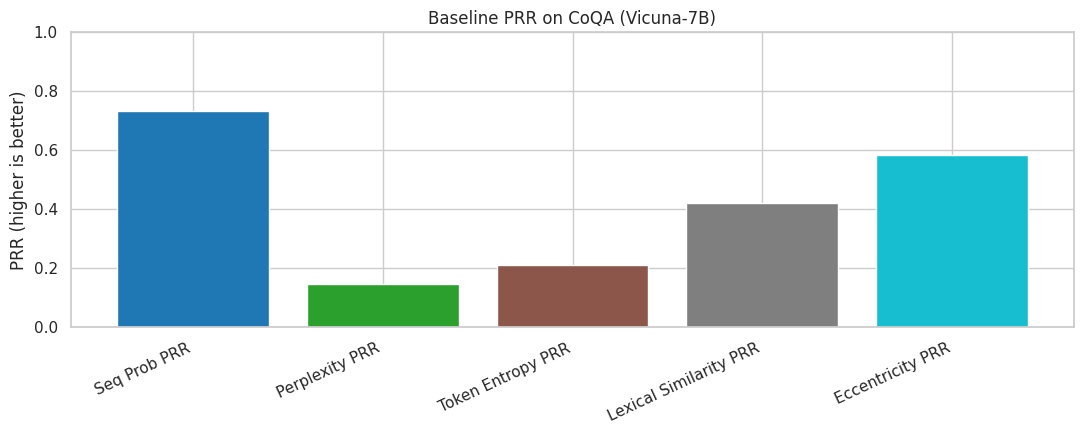

In [ ]:
baseline_row = {
    "Model": "Vicuna-7B",
    "Mean F1": round(vicuna_results["mean_f1"], 3),
}
baseline_row.update(
    {
        get_method_plot_label(method): round(vicuna_results[get_method_result_key(method)], 3)
        for method in CFG["methods"]
    }
)

df = pd.DataFrame([baseline_row])
display(df)

methods = [get_method_plot_label(method) for method in CFG["methods"]]
vals = [vicuna_results[get_method_result_key(method)] for method in CFG["methods"]]
colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(methods, vals, color=colors)
ax.set_ylim(0, 1)
ax.set_title("Baseline PRR on CoQA (Vicuna-7B)")
ax.set_ylabel("PRR (higher is better)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_prr_new.png", dpi=150)
plt.show()


In [ ]:
result_summary = {"mean_f1": vicuna_results["mean_f1"]}
for method in CFG["methods"]:
    result_summary[get_method_result_key(method)] = vicuna_results[get_method_result_key(method)]

baseline_payload = {
    "config": CFG,
    "results": result_summary,
}
save_json(str(OUTPUT_DIR / "baseline_results_new.json"), baseline_payload)
df.to_csv(OUTPUT_DIR / "baseline_prr_table_new.csv", index=False)
print("Saved: baseline_results.json, baseline_prr_table.csv, baseline_prr.png")


Saved: baseline_results.json, baseline_prr_table.csv, baseline_prr.png


## Reproduced Results
Use the table/figure outputs above in your report's **Reproduced Results** section.

## Resources
- GPU: printed in setup cell
- API resources: Hugging Face model hub and datasets

## Code
Add your GitHub repository link in the report's **Code** section.

## Notes
The two extension studies are in separate notebooks:
- `02_extension1_cross_model.ipynb`
- `03_extension2_sampling_sweep.ipynb`